# Обработка данных и EDA

Датасеты: train.csv (обучение), val.csv (проверка под дрейфом).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

In [2]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")
train.columns = train.columns.str.strip()
val.columns = val.columns.str.strip()

In [3]:
train

,ID,REGION,BRANCH,CITY,subject,SUBFRMT,TRADE_SQUARE,HuffFamilies,HuffRelativeFamilies,HOSPITAL,...,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,month_count,new_buildings,change_CA,target_1,target_2
0,1,Южный округ,Армавир,Кропоткин,Краснодарский край,2,0.445648,0.019780,0.83,0,...,1,0,3,0.550733,0,318,0,0,175198.181280689,174259.925193
1,2,Южный округ,Новороссийск Запад,Анапа,Краснодарский край,2,0.780890,0.060494,0.83,0,...,1,0,2,1.114666,0,317,0,0,360629.424460479,296286.063051
2,3,Южный округ,Ростов-на-Дону Запад,Таганрог,Ростовская область,2,0.471618,0.033680,0.84,0,...,1,0,2,3.730973,10,315,0,0,252109.534031112,250903.579740
3,4,Кавказский округ,Волгоград Восток,Камышин,Волгоградская область,2,0.555293,0.062644,0.76,0,...,1,0,3,1.039118,15,314,0,0,362653.018943467,351612.980992
4,5,Южный округ,Волгодонск,Волгодонск,Ростовская область,2,0.622970,0.030358,0.93,1,...,1,0,2,1.595111,0,314,0,0,295733.315192993,287970.899275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15104,15105,Сибирский округ,Красноярск,Красноярск,Красноярский край,1,0.419759,0.103733,0.64,0,...,1,0,1,11.306402,0,37,1,0,335833.03570864,335285.135791
15105,15106,Уральский округ,Ноябрьск,Правохеттинский,Ямало-Ненецкий автономный округ,1,0.523817,0.015207,0.48,0,...,1,0,3,0.251115,10,37,0,0,239449.710720112,245862.395965
15106,15107,Южный округ,Волгодонск,Синегорский,Ростовская область,1,0.426907,0.075626,0.54,0,...,1,0,3,1.170235,6,37,0,0,229265.834248059,223720.175478
15107,15108,Южный округ,Ростов-на-Дону Запад,Ростов-на-Дону,Ростовская область,1,0.807060,0.041533,0.93,0,...,1,0,3,6.246047,30,37,0,0,279075.187488385,278484.672897


In [4]:
val

,ID,REGION,BRANCH,CITY,subject,SUBFRMT,TRADE_SQUARE,HuffFamilies,HuffRelativeFamilies,HOSPITAL,...,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,month_count,new_buildings,change_CA,target_1,target_2
0,15110,Кавказский округ,Махачкала,Махачкала,Дагестан республика,1,0.543560,0.127906,0.36,0,...,1,0,3,5.014485,45,36,0,0,211284.017344,217852.573762
1,15111,Южно-Уральский округ,Уфа Восток,Старобалтачево,Башкортостан республика,1,0.512364,0.007974,0.95,0,...,1,0,3,0.997405,10,36,0,0,134375.436679,126017.434423
2,15112,Волжский округ,Тольятти,Тольятти,Самарская область,1,0.403160,0.036690,0.90,0,...,1,0,3,4.014383,22,36,0,0,236598.184183,241714.284607
3,15113,Сибирский округ,Барнаул,Барнаул,Алтайский край,1,0.578319,0.030293,0.95,0,...,1,0,3,8.090738,10,36,1,0,229031.825905,228827.849999
4,15114,Северо-Западный округ,Санкт-Петербург Центр,Санкт-Петербург,Санкт-Петербург город,1,1.000000,0.036474,0.87,0,...,1,0,3,10.674233,8,36,0,0,289192.336792,306755.018936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2063,17173,Южный округ,Ростов-на-Дону Запад,Николаевка,Ростовская область,1,0.644194,0.029994,0.57,0,...,1,1,4,9.326327,24,13,0,0,193496.420048,184377.226266
2064,17174,Сибирский округ,Красноярск,Шалинское,Красноярский край,1,0.633642,0.047762,0.45,0,...,1,0,3,0.493372,12,13,0,0,191787.007527,194000.555214
2065,17175,Московский округ,Москва 3,Раменское,Московская область,1,0.735799,0.045298,0.29,0,...,1,0,3,3.016680,8,13,0,0,254310.284746,252851.670013
2066,17176,Северо-Западный округ,Санкт-Петербург Восток,имени Свердлова,Ленинградская область,1,0.738442,0.022506,0.03,0,...,1,0,4,23.695526,30,13,0,0,217338.817958,211066.432513


In [5]:
print("train:", train.shape)
print("val:", val.shape)

train: (15109, 56)
val: (2068, 56)


In [6]:
def to_number(s):
    return pd.to_numeric(s.astype(str).str.replace(" ", "", regex=False), errors="coerce")
# Unable to parse string " 1 000 000 " at position 5817, поэтому убираем пробелы

In [7]:
train["target_1"] = to_number(train["target_1"])
val["target_1"] = to_number(val["target_1"])

## Обзор

Дубликатов ID

In [8]:
train["ID"].duplicated().sum()

np.int64(0)

In [9]:
train.dtypes.value_counts()

,count
int64,43
float64,9
object,4


In [10]:
train.head()

,ID,REGION,BRANCH,CITY,subject,SUBFRMT,TRADE_SQUARE,HuffFamilies,HuffRelativeFamilies,HOSPITAL,...,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,month_count,new_buildings,change_CA,target_1,target_2
0,1,Южный округ,Армавир,Кропоткин,Краснодарский край,2,0.445648,0.019780,0.83,0,...,1,0,3,0.550733,0,318,0,0,175198.181281,174259.925193
1,2,Южный округ,Новороссийск Запад,Анапа,Краснодарский край,2,0.780890,0.060494,0.83,0,...,1,0,2,1.114666,0,317,0,0,360629.424460,296286.063051
2,3,Южный округ,Ростов-на-Дону Запад,Таганрог,Ростовская область,2,0.471618,0.033680,0.84,0,...,1,0,2,3.730973,10,315,0,0,252109.534031,250903.579740
3,4,Кавказский округ,Волгоград Восток,Камышин,Волгоградская область,2,0.555293,0.062644,0.76,0,...,1,0,3,1.039118,15,314,0,0,362653.018943,351612.980992
4,5,Южный округ,Волгодонск,Волгодонск,Ростовская область,2,0.622970,0.030358,0.93,1,...,1,0,2,1.595111,0,314,0,0,295733.315193,287970.899275


## Пропуски



Кол-во пропусков

In [11]:
train.isna().sum().sum()

np.int64(0)

In [12]:
num_cols = train.select_dtypes(include=[np.number]).columns
zero = (train[num_cols] == 0).mean().sort_values(ascending=False)

Прямых пропусков в данных нет.

Колонки с наибольшим количеством нулей

In [13]:
(zero.head(10) * 100).round(1)

,0
METRO,99.8
HUB,99.7
SNT,99.5
huff_hotel,99.1
TRC,99.0
LOCATION_PARK,98.9
ALCOHOL,98.8
IN_COAL_CITY,98.8
ON_DUPLICATE_ROAD,98.7
SEA,98.6


## Целевая переменная
Сравнение target 1 и target 2

In [14]:
train[["target_1", "target_2"]].describe().round(0)

,target_1,target_2
count,15109.0,15109.0
mean,266942.0,263793.0
std,84076.0,84082.0
min,100000.0,100057.0
25%,208186.0,204749.0
50%,247125.0,244116.0
75%,305170.0,301946.0
max,1000000.0,987449.0


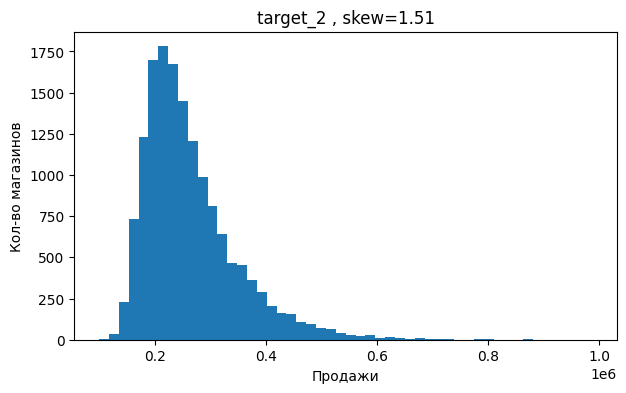

In [15]:
plt.figure(figsize=(7, 4))
plt.hist(train["target_2"], bins=50)
plt.title(f"target_2 , skew={train['target_2'].skew():.2f}")
plt.xlabel("Продажи")
plt.ylabel("Кол-во магазинов")
plt.show()

Посмотрев распределение целевой перменой, видно, что данные значительно скошены вправо (skew = 1.51). Для того, чтобы модели ошибались меньше, нужно будет логарифмировать целевую переменную перед обучением

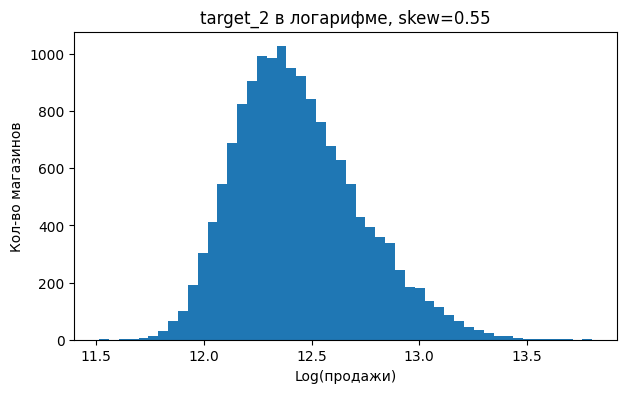

In [16]:
log_target = np.log(train["target_2"])
plt.figure(figsize=(7, 4))
plt.hist(log_target, bins=50)
plt.title(f"target_2 в логарифме, skew={log_target.skew():.2f}")
plt.xlabel("Log(продажи)")
plt.ylabel("Кол-во магазинов")
plt.show()

Видно, что скос стал значительно меньше

## Распределения числовых признаков

Смотрим, как устроены непрерывные признаки

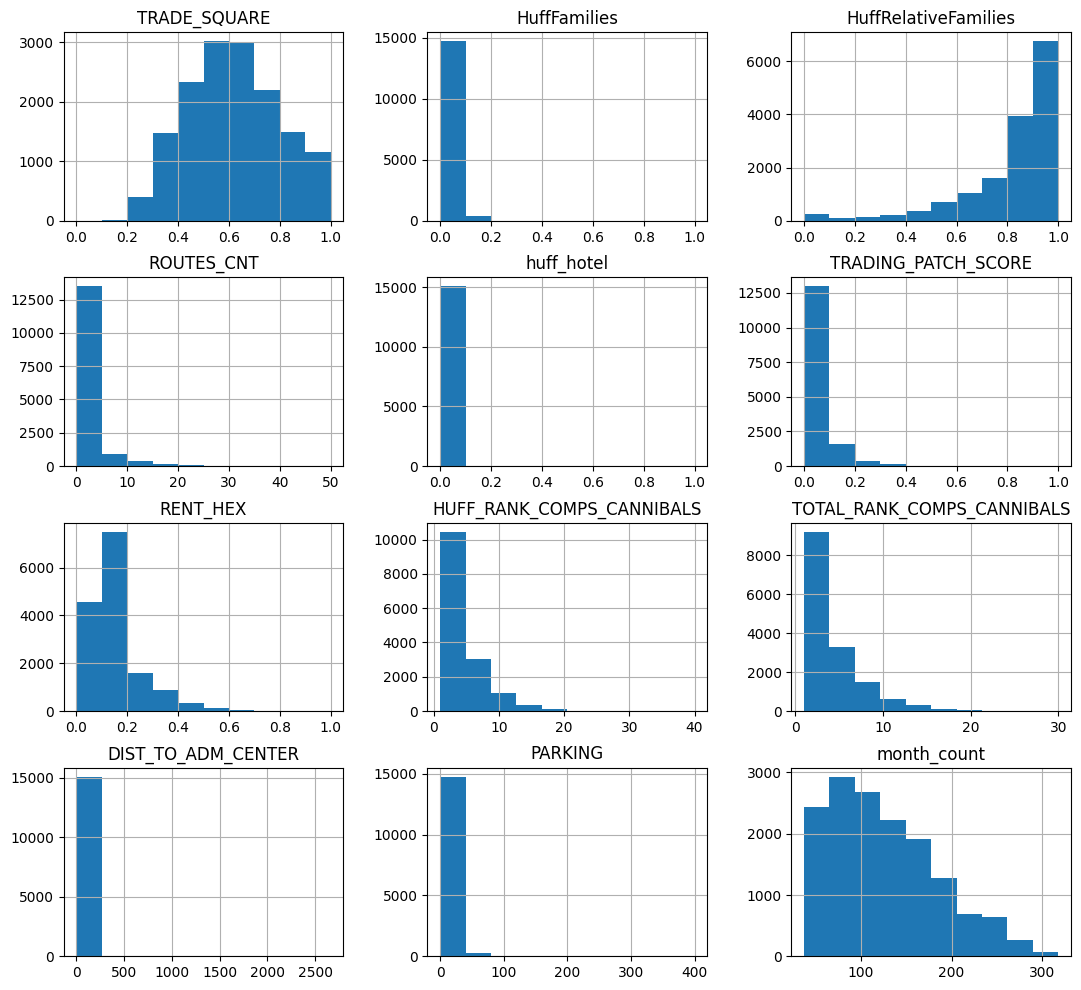

In [17]:
num = [i for i in train.select_dtypes("number").columns
        if i not in ["ID", "target_1", "target_2"] and train[i].nunique() > 15]
train[num].hist(figsize=(13, 12))
plt.show()

Считаем коэффициент асимметрии

In [18]:
skew = train[num].skew().sort_values(ascending=False)

Самые скошенные признаки

In [19]:
skew.head(10)

,0
DIST_TO_ADM_CENTER,53.709665
huff_hotel,38.245071
PARKING,6.888311
HuffFamilies,5.562393
ROUTES_CNT,4.698894
TRADING_PATCH_SCORE,3.402661
RENT_HEX,2.077622
HUFF_RANK_COMPS_CANNIBALS,2.075477
TOTAL_RANK_COMPS_CANNIBALS,1.956888
month_count,0.644629


Доля признаков с сильной скошенностью

In [20]:
(skew.abs() > 1).mean() * 100

np.float64(83.33333333333334)

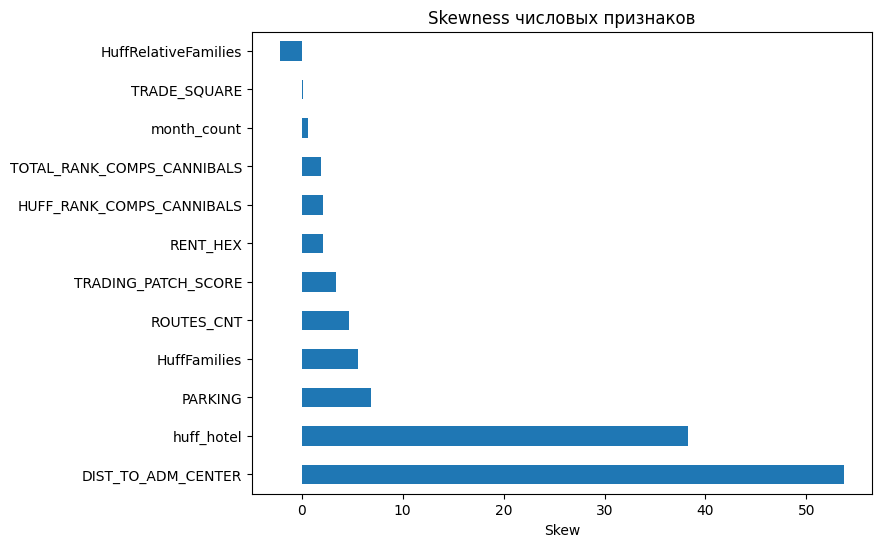

In [21]:
plt.figure(figsize=(8, 6))
skew.plot(kind="barh")
plt.title("Skewness числовых признаков")
plt.xlabel("Skew")
plt.show()

## Корреляции признаков

Ищем мультиколлинеарность. Это важно для линейной модели и подсказывает, где может помочь PCA

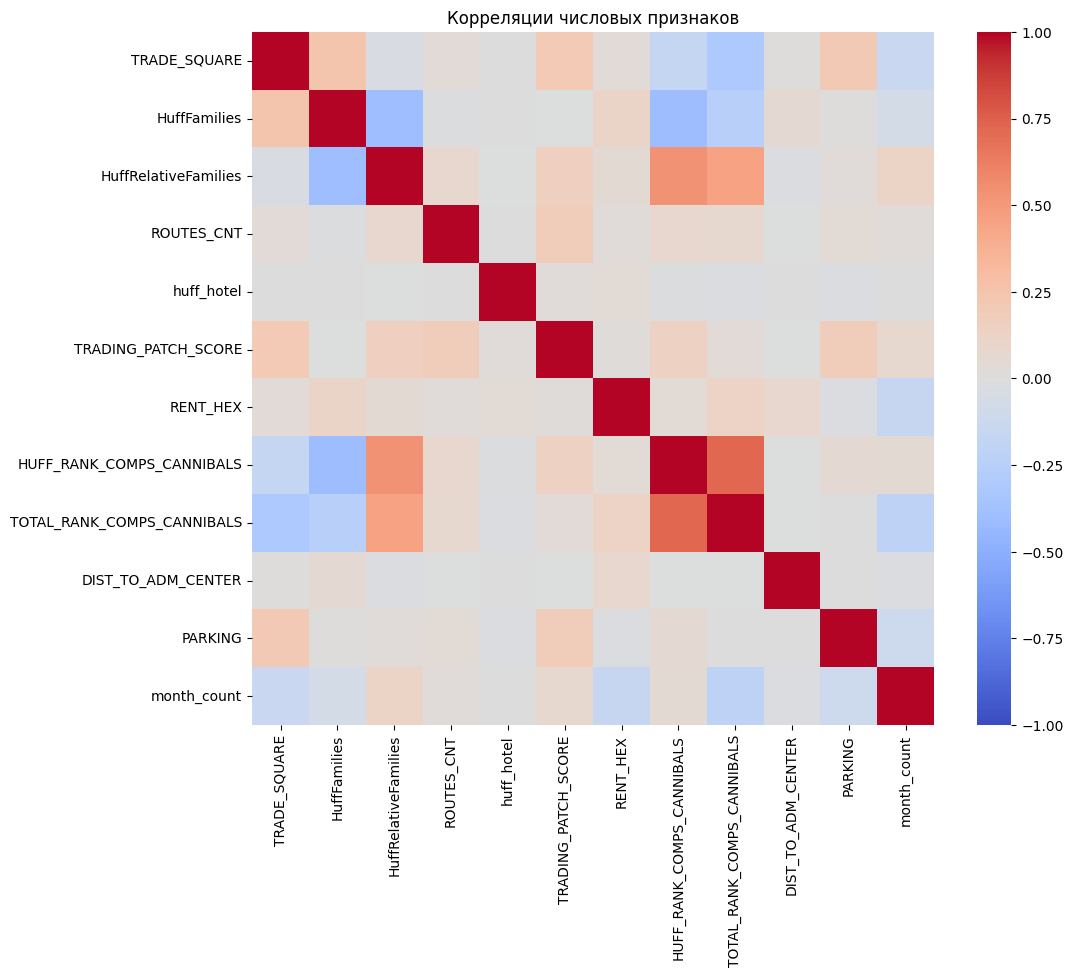

In [23]:
corr = train[num].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляции числовых признаков")
plt.show()

## Связь признаков с таргетом

Какие признаки сильнее всего связаны с продажами. Считаем корреляцию с log(target_2)

In [24]:
corr_target = train[num].corrwith(log_target).sort_values(key=abs, ascending=False)

Корреляция признаков с log(target_2)

In [25]:
corr_target.head(10).round(2)

,0
TRADE_SQUARE,0.45
HuffFamilies,0.40
RENT_HEX,0.34
HUFF_RANK_COMPS_CANNIBALS,-0.23
TOTAL_RANK_COMPS_CANNIBALS,-0.19
TRADING_PATCH_SCORE,0.18
PARKING,0.11
HuffRelativeFamilies,-0.09
month_count,-0.07
ROUTES_CNT,0.05


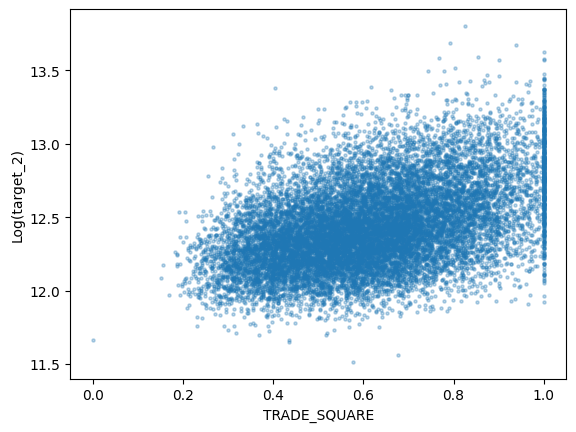

In [26]:
top_corr = corr_target.index[0]
plt.scatter(train[top_corr], log_target, s=5, alpha=0.3)
plt.xlabel(top_corr)
plt.ylabel("Log(target_2)")
plt.show()

## Категориальные признаки

In [27]:
categories = train.select_dtypes(include="object").columns
for i in categories:
    print(i, train[i].nunique(), "уникальных")

REGION 12 уникальных
BRANCH 97 уникальных
CITY 2763 уникальных
subject 66 уникальных


## Баланс выборок train и val

Сравниваем, насколько train и val похожи по целевой переменной.

Target_2 в train

In [28]:
train["target_2"].describe()[["mean", "50%", "std", "min", "max"]].round(0)

,target_2
mean,263793.0
50%,244116.0
std,84082.0
min,100057.0
max,987449.0


Target_2 в val

In [29]:
val["target_2"].describe()[["mean", "50%", "std", "min", "max"]].round(0)

,target_2
mean,235053.0
50%,219411.0
std,74540.0
min,109908.0
max,819255.0


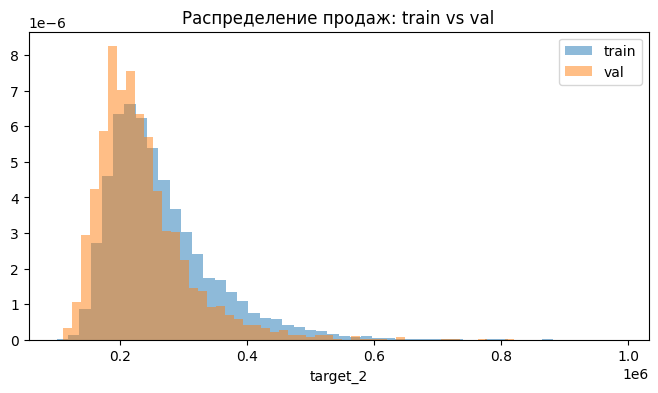

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(train["target_2"], bins=50, alpha=0.5, density=True, label="train")
plt.hist(val["target_2"], bins=50, alpha=0.5, density=True, label="val")
plt.title("Распределение продаж: train vs val")
plt.xlabel("target_2")
plt.legend()
plt.show()

## Дрейф между train и val

Главный вопрос задачи: насколько val отличается от train. Если сильно - модель,
обученная на train, будет хуже работать на новых данных

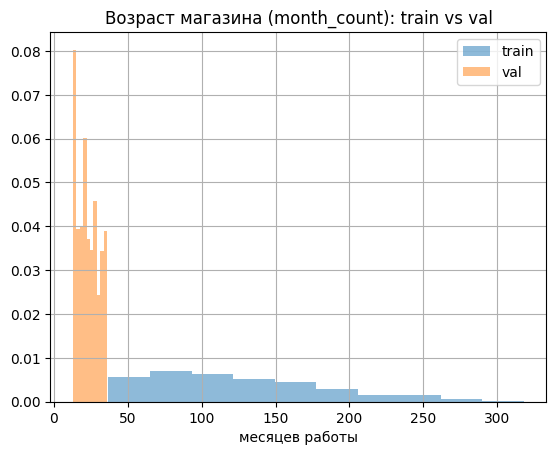

In [31]:
train["month_count"].hist(alpha=0.5, density=True, label="train")
val["month_count"].hist(alpha=0.5, density=True, label="val")
plt.legend()
plt.title("Возраст магазина (month_count): train vs val")
plt.xlabel("месяцев работы")
plt.show()

In [32]:
"медиана month_count - train:", int(train["month_count"].median()), "val:", int(val["month_count"].median())

('медиана month_count - train:', 115, 'val:', 22)

In [33]:
drop_cols = ["ID", "target_1", "target_2"]
X = pd.concat([train.drop(columns=drop_cols, errors="ignore"),
               val.drop(columns=drop_cols, errors="ignore")],
              ignore_index=True).select_dtypes("number")
y = np.r_[np.zeros(len(train)), np.ones(len(val))]

clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
proba = cross_val_predict(clf, X, y, cv=3, method="predict_proba")[:, 1]
print("Adversarial AUC:", round(roc_auc_score(y, proba), 3))

Adversarial AUC: 0.924


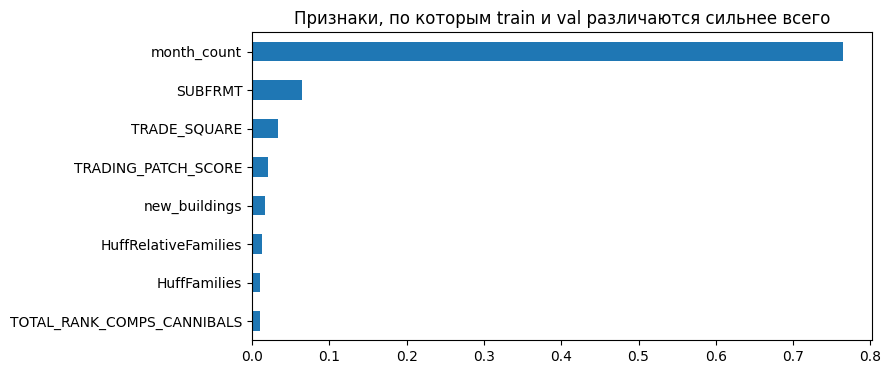

In [34]:
clf.fit(X, y)
importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values()
top8 = importance.tail(8)
top8.plot(kind="barh", figsize=(8, 4))
plt.title("Признаки, по которым train и val различаются сильнее всего")
plt.show()

In [35]:
top8.round(4)

,0
TOTAL_RANK_COMPS_CANNIBALS,0.0097
HuffFamilies,0.0099
HuffRelativeFamilies,0.0128
new_buildings,0.0172
TRADING_PATCH_SCORE,0.0203
TRADE_SQUARE,0.0335
SUBFRMT,0.0651
month_count,0.7640


## Краткие выводы

1. Пропусков нет.
2. Продажи скошены вправо - таргет стоит логарифмировать перед обучением.
3. CITY имеет тысячи значений - кодировать через target encoding.
4. Сильный дрейф между train и val (Adversarial AUC =0.92). Главный признак дрейфа - month_count. Модель надо строить устойчивой к этому сдвигу.
5. Большинство числовых признаков скошены вправо - логарифм делает их и таргет ближе к норме; это особенно важно для линейной модели, KNN и MLP.
6. Есть мультиколлинеарность среди Huff- и конкурентных признаков, возможно стоит удалить некоторые признаки.